# Intro to Supply x Demand
https://intro.quantecon.org/intro_supply_demand.html#isd_ex3

In [34]:
# import packages
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple

## A discrete example

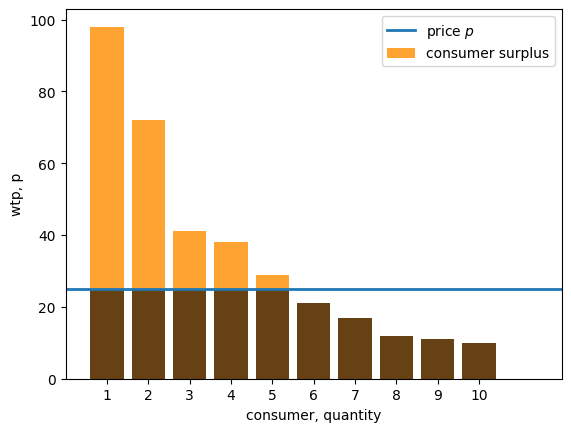

In [35]:
fig, ax = plt.subplots()
c = range(1, 11) 
wtp = (98, 72, 41, 38, 29, 21, 17, 12, 11, 10)
p = 25

ax.bar(c, wtp, label="consumer surplus", color="darkorange", alpha=0.8)
ax.plot((0, 12), (p, p), lw=2, label="price $p$")
ax.bar(c, [min(w, p) for w in wtp], color="black", alpha=0.6)
ax.set_xlim(0, 12)
ax.set_xticks(c)
ax.set_ylabel("wtp, p")
ax.set_xlabel("consumer, quantity")
ax.legend()
plt.show()

## Continuous approximation

In [36]:
def inverse_demand(q):
    """
    arg:
        q (float): quantity demanded
    """
    return 100 * np.exp(- q )

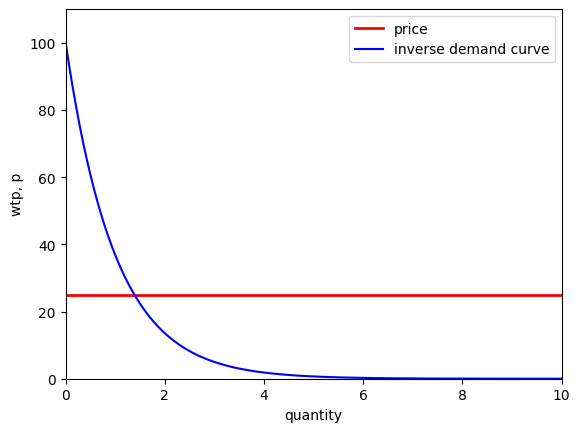

In [37]:
# build a quantity grid
q_min, q_max = 0, 10
q_grid = np.linspace(q_min, q_max, 1000)

# plot the inverse demand curve
fig, ax = plt.subplots()
ax.plot((q_min, q_max), (p, p), lw=2, label="price", color="red")
ax.plot(q_grid, inverse_demand(q_grid), 
        color="blue", label="inverse demand curve")
ax.set_ylabel("wtp, p")
ax.set_xlabel("quantity")
ax.set_xlim(q_min, q_max)
ax.set_ylim(0, 110)
ax.legend()
plt.show()

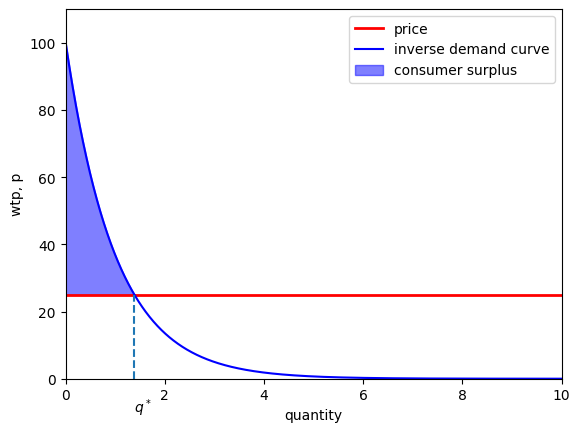

In [38]:
# Consumer surplus is the area under the demand curve and above the price

# solve for the value of q where demand = price
q_star = np.log(100) - np.log(p)

fig, ax = plt.subplots()
ax.plot((q_min, q_max), (p, p), lw=2, label="price", color="red")
ax.plot(q_grid, inverse_demand(q_grid), 
        color="blue", label="inverse demand curve")
small_grid = np.linspace(0, q_star, 500)
ax.fill_between(small_grid, np.full(len(small_grid), p),
                inverse_demand(small_grid), color="blue",
                alpha=0.5, label="consumer surplus")
ax.vlines(q_star, 0, p, ls="--")
ax.set_ylabel("wtp, p")
ax.set_xlabel("quantity")
ax.set_xlim(q_min, q_max)
ax.set_ylim(0, 110)
ax.text(q_star, -10, "$q^*$")
ax.legend()
plt.show()

## Producer Surplus

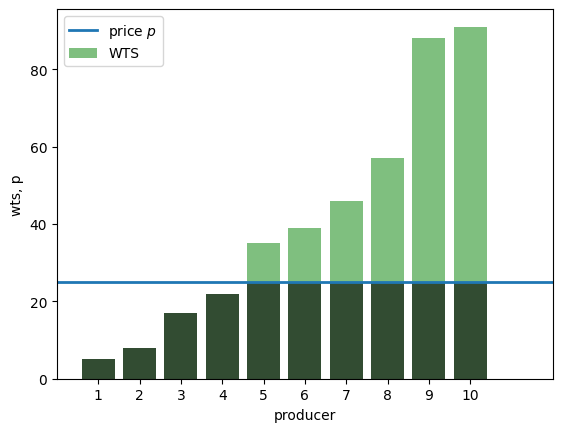

In [39]:
fig, ax = plt.subplots()
producers = range(1, 11)

#wts for each producer
wts = (5, 8, 17, 22, 35, 39, 46, 57, 88, 91)
p = 25

ax.bar(producers, wts, label="WTS", color="green", alpha=0.5)
ax.plot((0, 12), (p, p), lw=2, label="price $p$")
ax.bar(producers, [min(w, p) for w in wts], color="black", alpha=0.6)
ax.set_xlim(0, 12)
ax.set_xticks(producers)
ax.set_ylabel("wts, p")
ax.set_xlabel("producer")
ax.legend()
plt.show()

In [40]:
# inverse supply curve
def inverse_supply(q):
    """
    arg:
        q (float): quantity supplied
    """
    return 2 * q**2

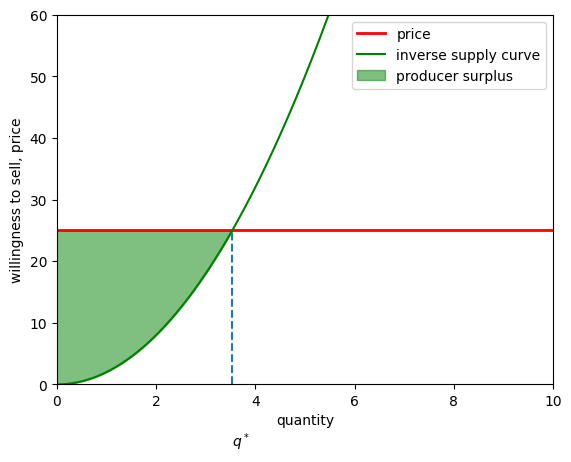

In [41]:
# solve for the value of q where supply meets price
q_star = (p / 2)**(1/2)

# plot inverse supply curve
fig, ax = plt.subplots()
ax.plot((q_min, q_max), (p, p), lw=2, label="price", color="red")
ax.plot(q_grid, inverse_supply(q_grid), 
        color="green", label="inverse supply curve")
small_grid = np.linspace(0, q_star, 500)
ax.fill_between(small_grid, inverse_supply(small_grid),
                np.full(len(small_grid), p), color="green",
                alpha=0.5, label="producer surplus")
ax.vlines(q_star, 0, p, ls="--")
ax.set_ylabel("willingness to sell, price")
ax.set_xlabel("quantity")
ax.set_xlim(q_min, q_max)
ax.set_ylim(0, 60)
ax.text(q_star, -10, "$q^*$")
ax.legend()
plt.show()

## Supply and Demand

In [42]:
# Market for a single good whichs buyers and sellers exchange q for p.
# assume affine quantity supplied and demanded functions
# q and p are both scalars

Market = namedtuple(
    'Market', ['d_0', # demand intercept
               'd_1', # demand slope
               's_0', # supply intercept
               's_1'] # supply slope
)

# create market
def create_market(d_0, d_1, s_0, s_1):
    """
    Create a market with given demand and supply parameters.
    """
    return Market(d_0=d_0, d_1=d_1, s_0=s_0, s_1=s_1)

def inverse_demand(q, model):
    """
    Calculate the price given a quantity demanded.
    """
    return model.d_0 - model.d_1 * q

def inverse_supply(q, model):
    """
    Calculate the price given a quantity supplied.
    """
    return model.s_0 + model.s_1 * q

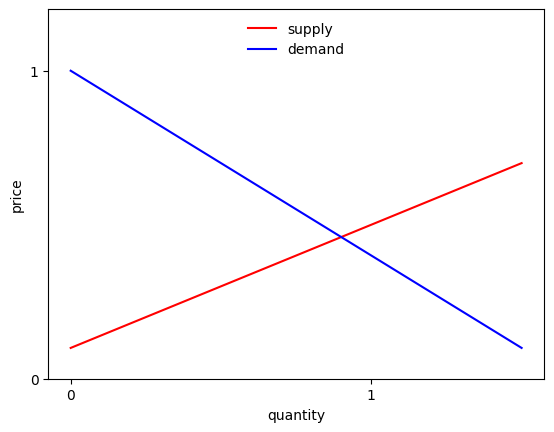

In [43]:
market = create_market(d_0=1.0, d_1=0.6, s_0=0.1, s_1=0.4)

grid_min, grid_max, grid_size = 0, 1.5, 200
q_grid = np.linspace(grid_min, grid_max, grid_size)
supply = inverse_supply(q_grid, market)
demand = inverse_demand(q_grid, market)

fig, ax = plt.subplots()
ax.plot(q_grid, supply, label='supply', color='red')
ax.plot(q_grid, demand, label='demand', color='blue')
ax.legend(loc='upper center', frameon=False)
ax.set_ylim(0, 1.2)
ax.set_xticks((0, 1))
ax.set_yticks((0, 1))
ax.set_xlabel('quantity')
ax.set_ylabel('price')
plt.show()

### consumer surplus

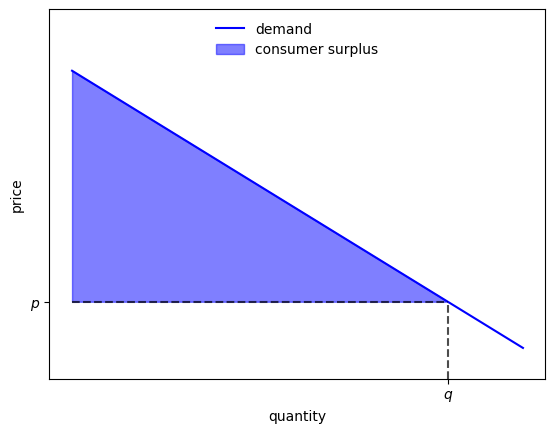

In [44]:
q = 1.25
p = inverse_demand(q, market)
ps = np.ones_like(q_grid) * p

fig, ax = plt.subplots()
ax.plot(q_grid, demand, label='demand', color='blue')
ax.fill_between(q_grid[q_grid <= q],
                demand[q_grid <= q],
                ps[q_grid <= q],
                label='consumer surplus', color='blue', alpha=0.5)
ax.vlines(q, 0, p, linestyle='--', color='black', alpha=0.7)
ax.hlines(p, 0, q, linestyle='--', color='black', alpha=0.7)
ax.legend(loc='upper center', frameon=False)
ax.set_ylim(0, 1.2)
ax.set_xticks((q,))
ax.set_xticklabels(("$q$",))
ax.set_yticks((p,))
ax.set_yticklabels(("$p$",))
ax.set_xlabel('quantity')
ax.set_ylabel('price')
plt.show()

### producer surplus

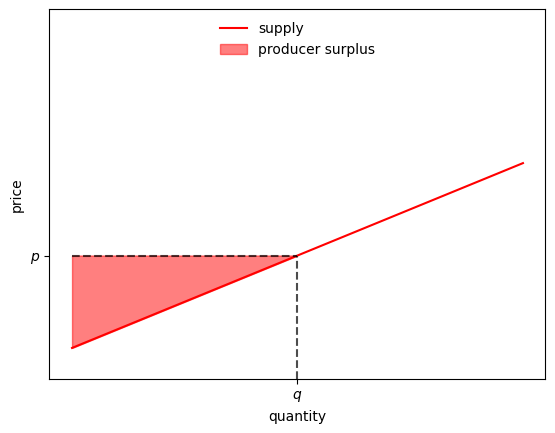

In [45]:
q = 0.75
p = inverse_supply(q, market)
ps = np.ones_like(q_grid) * p

fig, ax = plt.subplots()
ax.plot(q_grid, supply, label='supply', color='red')
ax.fill_between(q_grid[q_grid <= q],
                supply[q_grid <= q],
                ps[q_grid <= q],
                label='producer surplus',
                color="red",
                alpha=0.5)
ax.vlines(q, 0, p, linestyle="dashed", color='black', alpha=0.7)
ax.hlines(p, 0, q, linestyle="dashed", color='black', alpha=0.7)

ax.legend(loc='upper center', frameon=False)
ax.set_ylim(0, 1.2)
ax.set_xticks((q,))
ax.set_xticklabels(("$q$",))
ax.set_yticks((p,))
ax.set_yticklabels(("$p$",))
ax.set_xlabel('quantity')
ax.set_ylabel('price')
plt.show()

## Total Surplus

In [46]:
# total surplus is the sum of consumer and producer surplus
def W(q, market):
    """
    Calculate total surplus given quantity and market parameters.
    """
    return (market.d_0 - market.s_0 )* q - 0.5 * (market.d_1 + market.s_1) * q**2

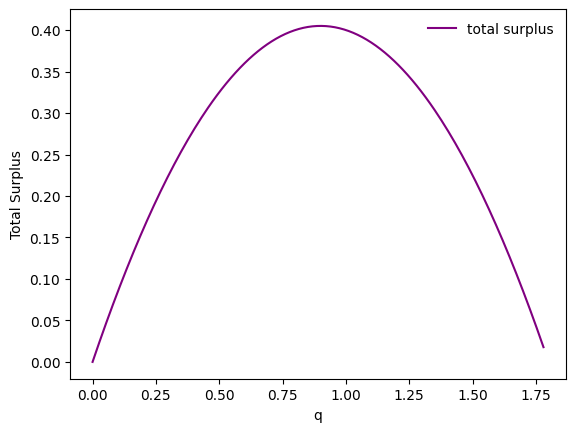

In [47]:
# plot total surplus as a function of quantity
q_vals = np.linspace(0, 1.78, 200)
fig, ax = plt.subplots()
ax.plot(q_vals, 
        W(q_vals, market),
        label='total surplus',
        color='purple')
ax.legend(frameon=False)
ax.set_xlabel('q')
ax.set_ylabel('Total Surplus')
plt.show()

### Excercies

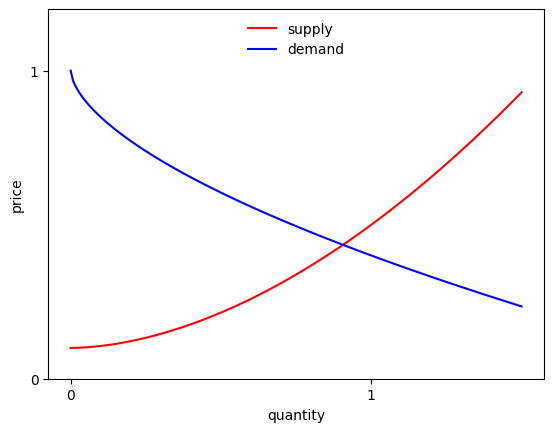

In [48]:
# 7.1
def inverse_demand_2(q, model):
    """
    Calculate the price given a quantity demanded.
    """
    return model.d_0 - model.d_1 * q**0.6

def inverse_supply_2(q, model):
    """
    Calculate the price given a quantity supplied.
    """
    return model.s_0 + model.s_1 * q**1.8

market = create_market(d_0=1.0, d_1=0.6, s_0=0.1, s_1=0.4)

grid_min, grid_max, grid_size = 0, 1.5, 200
q_grid = np.linspace(grid_min, grid_max, grid_size)
supply = inverse_supply_2(q_grid, market)
demand = inverse_demand_2(q_grid, market)

fig, ax = plt.subplots()
ax.plot(q_grid, supply, label='supply', color='red')
ax.plot(q_grid, demand, label='demand', color='blue')
ax.legend(loc='upper center', frameon=False)
ax.set_ylim(0, 1.2)
ax.set_xticks((0, 1))
ax.set_yticks((0, 1))
ax.set_xlabel('quantity')
ax.set_ylabel('price')
plt.show()